In [4]:
# ======================= EXTRA TREES MODEL + PARTIAL SMOTE + TOMEK LINKS (TRAIN SET ONLY) =======================
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score
)
from imblearn.combine import SMOTETomek
from collections import Counter

# --- Load Data ---
train_data = pd.read_csv('/content/drive/MyDrive/Senior_Project/train_split.csv')
test_data  = pd.read_csv('/content/drive/MyDrive/Senior_Project/test_split.csv')


# --- Features & Target ---
features = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES',
            'DEWP', 'RAIN', 'WSPM', 'wd_sin', 'wd_cos']

X_train = train_data[features].values
y_train = train_data['PM2.5_level'].values - 1
X_test  = test_data[features].values
y_test  = test_data['PM2.5_level'].values - 1

# ===============================
# Partial SMOTE + Tomek (Train Set ทั้งก้อน)
# ===============================
print("Before Partial SMOTE+Tomek:", Counter(y_train))

max_class_count = max(Counter(y_train).values())
target_size = int(max_class_count * 0.5)  # oversample บางคลาสถึง 50% ของคลาสใหญ่สุด

sampling_strategy = {}
for c in [1, 2]:  # class 2,3 เดิม → 1,2 หลัง shift
    if Counter(y_train).get(c, 0) < target_size:
        sampling_strategy[c] = target_size

if sampling_strategy:
    smt = SMOTETomek(sampling_strategy=sampling_strategy, random_state=42)
    X_train_res, y_train_res = smt.fit_resample(X_train, y_train)
    print("After Partial SMOTE+Tomek:", Counter(y_train_res))
else:
    X_train_res, y_train_res = X_train, y_train
    print("No resampling applied.")

# ===============================
# 10-Fold Cross Validation (ใช้ข้อมูลที่ Oversample แล้ว)
# ===============================
kf = KFold(n_splits=10, shuffle=True, random_state=42)

accuracies, precisions, recalls, f1_scores, auc_scores = [], [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_res), 1):
    X_fold_train, X_fold_val = X_train_res[train_idx], X_train_res[val_idx]
    y_fold_train, y_fold_val = y_train_res[train_idx], y_train_res[val_idx]

    # --- Extra Trees Model (Default Parameters) ---
    model = ExtraTreesClassifier(random_state=42)  # ✅ ใช้ค่ามาตรฐานทั้งหมด
    model.fit(X_fold_train, y_fold_train)


    model.fit(X_fold_train, y_fold_train)

    y_pred = model.predict(X_fold_val)
    y_pred_proba = model.predict_proba(X_fold_val)

    acc = accuracy_score(y_fold_val, y_pred)
    precision = precision_score(y_fold_val, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_fold_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_fold_val, y_pred, average='weighted', zero_division=0)
    y_bin = label_binarize(y_fold_val, classes=[0, 1, 2, 3, 4])
    auc = roc_auc_score(y_bin, y_pred_proba, average='macro', multi_class='ovo')

    accuracies.append(acc)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    auc_scores.append(auc)

    print(f"Fold {fold}: Accuracy={acc:.3f}, Precision={precision:.3f}, "
          f"Recall={recall:.3f}, F1={f1:.3f}, AUC={auc:.3f}")

print("\n================ Cross-Validation Results ================")
print(f"Accuracy:  {np.mean(accuracies):.3f} ± {np.std(accuracies):.3f}")
print(f"Precision: {np.mean(precisions):.3f} ± {np.std(precisions):.3f}")
print(f"Recall:    {np.mean(recalls):.3f} ± {np.std(recalls):.3f}")
print(f"F1-score:  {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
print(f"AUC-ROC:   {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}")

# ===============================
# Final Model (ค่า Default ทั้งหมด)
# ===============================
final_model = ExtraTreesClassifier(random_state=42)
final_model.fit(X_train_res, y_train_res)


# ===============================
# Evaluate on Test Set
# ===============================
y_pred_test = final_model.predict(X_test)
y_pred_proba_test = final_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

test_accuracy  = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_recall    = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1        = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_auc       = roc_auc_score(y_test_bin, y_pred_proba_test, average='macro', multi_class='ovo')

print("\n================ Test Set Results (Final Model) ================")
print(f"Accuracy:           {test_accuracy:.3f}")
print(f"Weighted Precision: {test_precision:.3f}")
print(f"Weighted Recall:    {test_recall:.3f}")
print(f"Weighted F1-score:  {test_f1:.3f}")
print(f"Macro AUC-ROC:      {test_auc:.3f}")

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test,
                            target_names=['Good', 'Moderate',
                                          'Unhealthy for Sensitive',
                                          'Unhealthy', 'Very Unhealthy'],
                            zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))

Before Partial SMOTE+Tomek: Counter({np.int64(4): 128801, np.int64(3): 73062, np.int64(0): 64314, np.int64(1): 33504, np.int64(2): 29942})
After Partial SMOTE+Tomek: Counter({np.int64(4): 123151, np.int64(3): 65305, np.int64(2): 61604, np.int64(0): 61200, np.int64(1): 60907})
Fold 1: Accuracy=0.873, Precision=0.872, Recall=0.873, F1=0.872, AUC=0.982
Fold 2: Accuracy=0.872, Precision=0.871, Recall=0.872, F1=0.871, AUC=0.981
Fold 3: Accuracy=0.869, Precision=0.868, Recall=0.869, F1=0.869, AUC=0.981
Fold 4: Accuracy=0.870, Precision=0.869, Recall=0.870, F1=0.869, AUC=0.981
Fold 5: Accuracy=0.872, Precision=0.871, Recall=0.872, F1=0.871, AUC=0.981
Fold 6: Accuracy=0.872, Precision=0.871, Recall=0.872, F1=0.871, AUC=0.981
Fold 7: Accuracy=0.870, Precision=0.870, Recall=0.870, F1=0.870, AUC=0.981
Fold 8: Accuracy=0.870, Precision=0.870, Recall=0.870, F1=0.870, AUC=0.981
Fold 9: Accuracy=0.869, Precision=0.868, Recall=0.869, F1=0.868, AUC=0.981
Fold 10: Accuracy=0.871, Precision=0.870, Recall

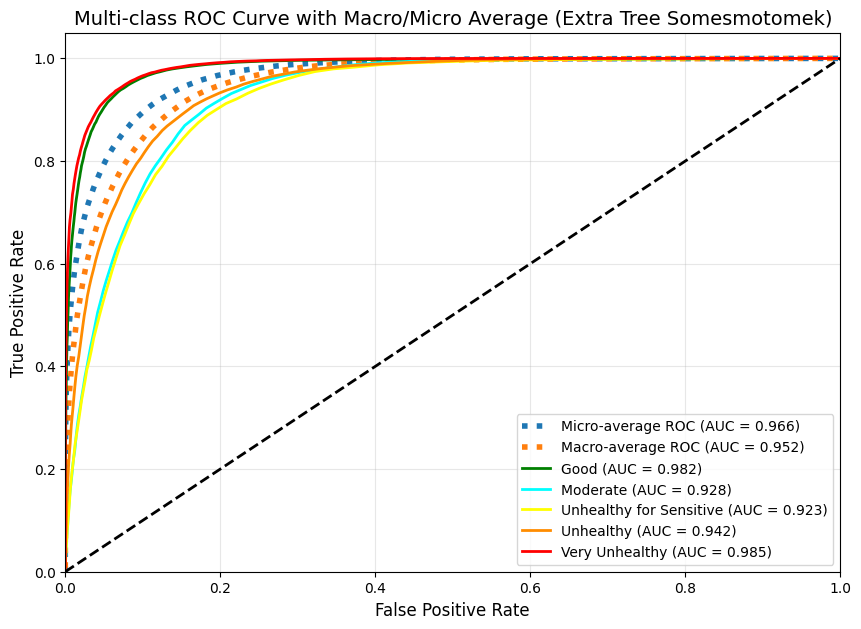

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# ============================================
# Multi-class ROC Curve (Test Set)
# ============================================

n_classes = y_test_bin.shape[1]

# คำนวณ ROC curve และ AUC สำหรับแต่ละ class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# คำนวณ micro-average ROC curve และ AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba_test.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# คำนวณ macro-average ROC curve และ AUC
# รวม FPR ทั้งหมดของทุก class แล้วทำ interpolation
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# ============================================
# Plot ROC Curves
# ============================================

plt.figure(figsize=(10, 7))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
         linestyle=':', linewidth=4)
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-average ROC (AUC = {roc_auc["macro"]:.3f})',
         linestyle=':', linewidth=4)

# Plot ROC ของแต่ละ class
colors = cycle(['green', 'aqua', 'yellow', 'darkorange', 'red'])
class_names = ['Good', 'Moderate', 'Unhealthy for Sensitive', 'Unhealthy', 'Very Unhealthy']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC Curve with Macro/Micro Average (Extra Tree Somesmotomek)', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()


In [6]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Binarize y_test
classes = [0, 1, 2, 3, 4]
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# คำนวณ fpr, tpr สำหรับแต่ละคลาส
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# รวม fpr ทั้งหมด
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate tpr
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_roc_auc = auc(all_fpr, mean_tpr)

# 🔽 Save fpr & tpr for later use
roc_df = pd.DataFrame({'fpr': all_fpr, 'tpr': mean_tpr})
roc_df.to_csv("roc_data_ETSomesmotomek.csv", index=False)

# ✅ Print AUC and preview
print("Macro AUC =", round(macro_roc_auc, 4))
print(roc_df.head())


Macro AUC = 0.9518
        fpr       tpr
0  0.000000  0.007725
1  0.000013  0.025242
2  0.000014  0.025692
3  0.000016  0.029127
4  0.000027  0.043960
